In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency, f_oneway, ttest_ind

class Ecommerce:
    def __init__(self, df=None, filename=None):
        if filename:
            self.df = pd.read_csv(filename)
        elif df is not None:
            self.df = df
            
    def head(self, n=5):
        print(self.df.head(n))
    
    def tail(self, n=5):
        print(self.df.tail(n))
    
    def shape(self):
        return self.df.shape
    
    def columns(self):
        return self.df.columns.tolist()
    
    def info(self):
        return self.df.info()
    
    def describe(self):
        return self.df.describe(include='all')
    
    def data_types(self):
        return self.df.dtypes
    
    def unique_counts(self):
        return self.df.nunique()
    
    def statistics(self):
        return self.df.describe()
    
    def categorical_summary(self):
        return self.df.describe(include='object')
    
    
    def find_null(self):
        return self.df.isnull().sum()
    
    def null_percentage(self):
        return (self.df.isnull().mean() * 100).round(2)
    
    def fillna_with_mode(self, col):
        if self.df[col].isnull().sum() > 0:
            mode_val = self.df[col].mode()[0]
            self.df[col] = self.df[col].fillna(mode_val)
    
    def drop_nulls(self):
        self.df.dropna(inplace=True)
    
    def find_duplicated(self):
        return self.df[self.df.duplicated()]
    
    def drop_duplicates(self):
        self.df.drop_duplicates(inplace=True)
        print("Duplicates removed.")
    
    def drop_column(self, col):
        self.df.drop(columns=[col], inplace=True)
    
    def filter_rows(self, condition):
        return self.df.query(condition)
    
    def convert_dtype(self, col, dtype):
        self.df[col] = self.df[col].astype(dtype)
    
    def find_columns_with_outliers(self):
        numeric_cols = self.df.select_dtypes(include=['int64', 'float64']).columns
        outlier_columns = []
        
        for col in numeric_cols:
            col_data = pd.to_numeric(self.df[col], errors='coerce').dropna()
            Q1 = col_data.quantile(0.25)
            Q3 = col_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
            
            if not outliers.empty:
                outlier_columns.append(col)
        
        return outlier_columns


    
    def detect_outlier(self, column_name):
        col = pd.to_numeric(self.df[column_name], errors='coerce').dropna()
        Q1 = col.quantile(0.25)
        Q3 = col.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = self.df[(self.df[column_name] < lower_bound) | (self.df[column_name] > upper_bound)]
        return outliers[column_name].tolist()
    
    
    def plot_distribution(self, column):
        plt.figure(figsize=(8, 4))
        sns.histplot(self.df[column], kde=True)
        plt.title(f"Distribution of {column}")
        plt.show()
    
    def plot_count(self, column):
        plt.figure(figsize=(8, 4))
        sns.countplot(x=self.df[column])
        plt.title(f"Count Plot of {column}")
        plt.xticks(rotation=45)
        plt.show()
    
    def box_plots(self, name):
        plt.figure(figsize=(6, 4))
        sns.boxplot(y=self.df[name], color='skyblue')
        plt.title(f'Boxplot of {name}')
        plt.show()
    
    def plot_pie(self, column):
        self.df[column].value_counts().plot.pie(autopct="%1.1f%%", figsize=(6, 6), title=f"Pie Chart of {column}")
        plt.ylabel('')
        plt.show()
    
    def plot_bar(self, column):
        self.df[column].value_counts().plot.bar(figsize=(8, 4), title=f"Bar Chart of {column}")
        plt.xticks(rotation=45)
        plt.show()
    
    def plot_kde(self, column):
        plt.figure(figsize=(8, 4))
        sns.kdeplot(self.df[column], shade=True)
        plt.title(f"KDE Plot of {column}")
        plt.show()
    
    def plot_scatter(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=self.df[x], y=self.df[y])
        plt.title(f"Scatter Plot: {x} vs {y}")
        plt.show()
    
    def plot_line(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.lineplot(x=self.df[x], y=self.df[y])
        plt.title(f"Line Plot: {x} vs {y}")
        plt.show()
    
    def plot_stacked_bar(self, col1, col2):
        pd.crosstab(self.df[col1], self.df[col2]).plot(kind="bar", stacked=True, figsize=(10, 6))
        plt.title(f"Stacked Bar Plot: {col1} vs {col2}")
        plt.show()
    
    def plot_violin(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.violinplot(x=self.df[x], y=self.df[y])
        plt.title(f"Violin Plot: {x} vs {y}")
        plt.show()
    
    def plot_pair(self, cols=None):
        sns.pairplot(self.df if cols is None else self.df[cols], diag_kind='kde')
        plt.suptitle("Pair Plot", y=1.02)
        plt.show()
    
    def plot_strip(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.stripplot(x=self.df[x], y=self.df[y], jitter=True)
        plt.title(f"Strip Plot: {x} vs {y}")
        plt.show()
    
    def plot_swarm(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.swarmplot(x=self.df[x], y=self.df[y])
        plt.title(f"Swarm Plot: {x} vs {y}")
        plt.show()
    
    def correlation_heatmap(self):
        plt.figure(figsize=(10, 8))
        sns.heatmap(self.df.corr(numeric_only=True), annot=True, cmap='coolwarm')
        plt.title("Correlation Heatmap")
        plt.show()
    
    def regression_plot(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.regplot(x=self.df[x], y=self.df[y], scatter_kws={'s': 10}, line_kws={'color': 'red'})
        plt.title(f"Regression Plot: {x} vs {y}")
        plt.show()
    
   
    
    def sales_by_category(self, category_col='category_code', sales_col='price'):
        sales_by_cat = self.df.groupby(category_col)[sales_col].sum().sort_values(ascending=False)
        sales_by_cat.plot.bar(figsize=(10, 5), color='teal')
        plt.title("Sales by Category")
        plt.xlabel("Category")
        plt.ylabel("Total Sales")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    def chi_square(self, col1, col2):
        table = pd.crosstab(self.df[col1], self.df[col2])
        _, p, _, _ = chi2_contingency(table)
        return p
    
    def continuous_vs_continuous_correlation(self):
        corr_matrix = self.df.select_dtypes(include=['int64', 'float64']).corr()
        correlated_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                col1 = corr_matrix.columns[i]
                col2 = corr_matrix.columns[j]
                corr_value = corr_matrix.iloc[i, j]
                correlated_pairs.append((col1, col2, corr_value))
        return sorted(correlated_pairs, key=lambda x: abs(x[2]), reverse=True)
    
    def anova_test(self, target):
        continuous_cols = self.df.select_dtypes(include=['int64', 'float64']).columns
        categorical_cols = self.df.select_dtypes(include='object').columns
        results = []
        for cat in categorical_cols:
            if self.df[cat].nunique() > 1:
                groups = [group[target].dropna().values for _, group in self.df.groupby(cat) if len(group[target].dropna()) > 1]
                if len(groups) > 1:
                    stat, p = f_oneway(*groups)
                    results.append({'Feature': cat, 'ANOVA_p_value': round(p, 4)})
        return pd.DataFrame(results)
    
    def t_test(self, cat_col, target):
        groups = self.df[cat_col].dropna().unique()
        if len(groups) != 2:
            raise ValueError("T-test is only applicable for binary categorical variables")
        group1 = self.df[self.df[cat_col] == groups[0]][target].dropna()
        group2 = self.df[self.df[cat_col] == groups[1]][target].dropna()
        stat, p = ttest_ind(group1, group2)
        return p
    
    def save_to_csv(self, filename):
        self.df.to_csv(filename, index=False)


In [17]:
Ecom=Ecommerce(filename="data.csv")

In [15]:
Ecom.head()

    Order ID Customer ID Platform Order Date & Time  Delivery Time (Minutes)  \
0  ORD000001    CUST2824  JioMart           19:29.5                       30   
1  ORD000002    CUST1409  Blinkit           54:29.5                       16   
2  ORD000003    CUST5506  JioMart           21:29.5                       25   
3  ORD000004    CUST5012  JioMart           19:29.5                       42   
4  ORD000005    CUST4657  Blinkit           49:29.5                       30   

      Product Category  Order Value (INR)              Customer Feedback  \
0  Fruits & Vegetables                382  Fast delivery, great service!   
1                Dairy                279            Quick and reliable!   
2            Beverages                599      Items missing from order.   
3            Beverages                946      Items missing from order.   
4            Beverages                334  Fast delivery, great service!   

   Service Rating Delivery Delay Refund Requested  
0         

In [24]:
Ecom.tail()

       Order ID Customer ID          Platform Order Date & Time  \
8995  ORD067052    CUST4230           Blinkit           40:29.5   
8996  ORD070642    CUST1373           Blinkit           18:29.5   
8997  ORD070769    CUST9546           Blinkit           27:29.5   
8998  ORD074930    CUST5048           Blinkit           30:29.5   
8999  ORD083876    CUST2135  Swiggy Instamart           26:29.5   

      Delivery Time (Minutes) Product Category  Order Value (INR)  \
8995                       30           Snacks                326   
8996                       36           Snacks                138   
8997                       20            Dairy                113   
8998                       17    Personal Care               1217   
8999                       32    Personal Care                235   

                               Customer Feedback  Service Rating  \
8995                         Quick and reliable!               5   
8996  Horrible experience, never ordering agai

In [23]:
Ecom.shape()

(9000, 11)

In [17]:
Ecom.columns()

['Order ID',
 'Customer ID',
 'Platform',
 'Order Date & Time',
 'Delivery Time (Minutes)',
 'Product Category',
 'Order Value (INR)',
 'Customer Feedback',
 'Service Rating',
 'Delivery Delay',
 'Refund Requested']

In [18]:
Ecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Order ID                 9000 non-null   object
 1   Customer ID              9000 non-null   object
 2   Platform                 9000 non-null   object
 3   Order Date & Time        9000 non-null   object
 4   Delivery Time (Minutes)  9000 non-null   int64 
 5   Product Category         9000 non-null   object
 6   Order Value (INR)        9000 non-null   int64 
 7   Customer Feedback        9000 non-null   object
 8   Service Rating           9000 non-null   int64 
 9   Delivery Delay           9000 non-null   object
 10  Refund Requested         9000 non-null   object
dtypes: int64(3), object(8)
memory usage: 773.6+ KB


In [19]:
Ecom.describe()

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
count,9000,9000,9000,9000,9000.000000,9000,9000.000000,9000,9000.000000,9000,9000
unique,9000,9000,3,60,NaN,6,NaN,13,NaN,2,2
top,ORD000001,CUST2824,Blinkit,29:29.5,NaN,Snacks,NaN,Delivery person was rude.,NaN,No,No
freq,1,1,3060,182,NaN,1530,NaN,728,NaN,7724,4848
mean,NaN,NaN,NaN,NaN,29.545000,NaN,591.874222,NaN,3.237889,NaN,NaN
std,NaN,NaN,NaN,NaN,10.034244,NaN,418.214454,NaN,1.572053,NaN,NaN
min,NaN,NaN,NaN,NaN,5.000000,NaN,50.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,23.000000,NaN,282.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,30.000000,NaN,479.000000,NaN,3.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,36.000000,NaN,774.000000,NaN,5.000000,NaN,NaN


In [25]:
Ecom.data_types()

Order ID                   object
Customer ID                object
Platform                   object
Order Date & Time          object
Delivery Time (Minutes)     int64
Product Category           object
Order Value (INR)           int64
Customer Feedback          object
Service Rating              int64
Delivery Delay             object
Refund Requested           object
dtype: object

In [26]:
Ecom.unique_counts()

Order ID                   9000
Customer ID                9000
Platform                      3
Order Date & Time            60
Delivery Time (Minutes)      60
Product Category              6
Order Value (INR)          1634
Customer Feedback            13
Service Rating                5
Delivery Delay                2
Refund Requested              2
dtype: int64

In [27]:
Ecom.statistics()

,Delivery Time (Minutes),Order Value (INR),Service Rating
count,9000.000000,9000.000000,9000.000000
mean,29.545000,591.874222,3.237889
std,10.034244,418.214454,1.572053
min,5.000000,50.000000,1.000000
25%,23.000000,282.000000,2.000000
50%,30.000000,479.000000,3.000000
75%,36.000000,774.000000,5.000000
max,65.000000,2000.000000,5.000000


In [28]:
Ecom.categorical_summary()

,Order ID,Customer ID,Platform,Order Date & Time,Product Category,Customer Feedback,Delivery Delay,Refund Requested
count,9000,9000,9000,9000,9000,9000,9000,9000
unique,9000,9000,3,60,6,13,2,2
top,ORD000001,CUST2824,Blinkit,29:29.5,Snacks,Delivery person was rude.,No,No
freq,1,1,3060,182,1530,728,7724,4848


In [29]:
Ecom.find_null()

Order ID                   0
Customer ID                0
Platform                   0
Order Date & Time          0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
Refund Requested           0
dtype: int64

In [30]:
Ecom.null_percentage()

Order ID                   0.0
Customer ID                0.0
Platform                   0.0
Order Date & Time          0.0
Delivery Time (Minutes)    0.0
Product Category           0.0
Order Value (INR)          0.0
Customer Feedback          0.0
Service Rating             0.0
Delivery Delay             0.0
Refund Requested           0.0
dtype: float64

In [20]:
Ecom.drop_duplicates()

Duplicates removed.


In [54]:
Ecom.find_columns_with_outliers()

['Delivery Time (Minutes)', 'Order Value (INR)']

In [60]:
Ecom.detect_outlier('Delivery Time (Minutes)')

[60,
 61,
 57,
 58,
 59,
 59,
 61,
 56,
 60,
 57,
 58,
 60,
 59,
 56,
 58,
 59,
 57,
 56,
 56,
 57,
 64,
 56,
 56,
 57,
 62,
 57,
 62,
 57,
 62,
 59,
 59,
 56,
 56,
 57,
 56,
 56,
 56,
 58,
 56,
 57,
 60,
 56,
 59,
 56,
 56,
 65,
 57,
 61,
 58,
 58]

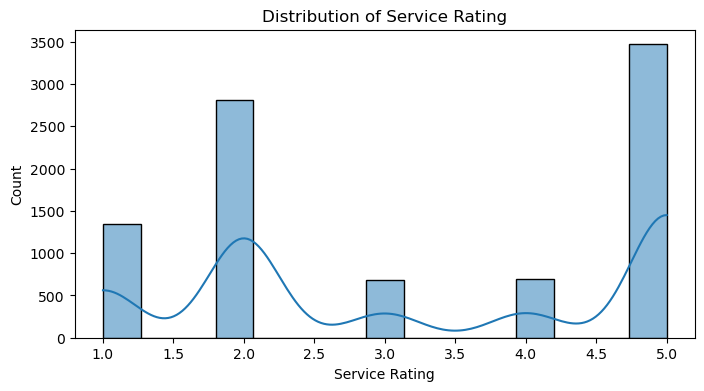

In [63]:
Ecom.plot_distribution('Service Rating')

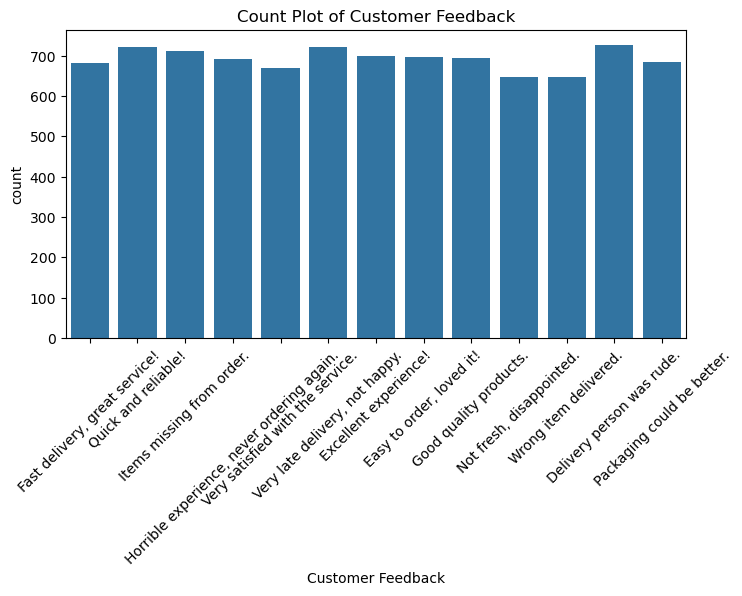

In [62]:
Ecom.plot_count('Customer Feedback')

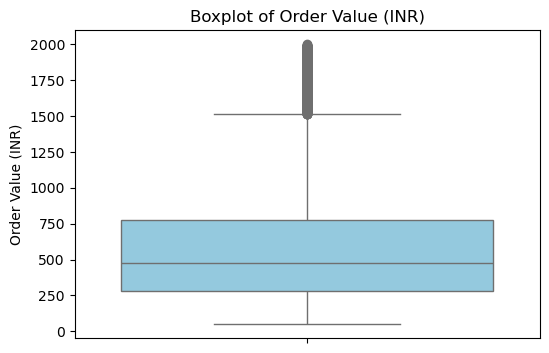

In [65]:
Ecom.box_plots('Order Value (INR)')

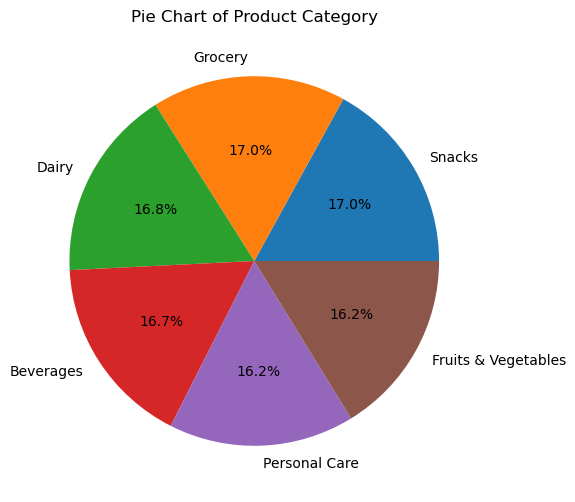

In [66]:
Ecom.plot_pie('Product Category')

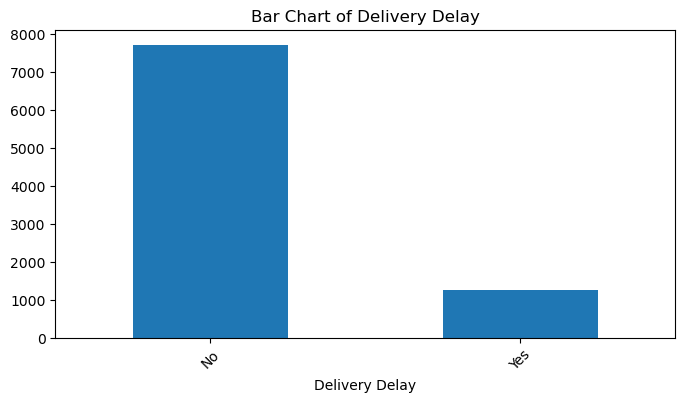

In [67]:
Ecom.plot_bar('Delivery Delay')

C:\Users\HP\AppData\Local\Temp\ipykernel_18004\2549126260.py:138: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(self.df[column], shade=True)


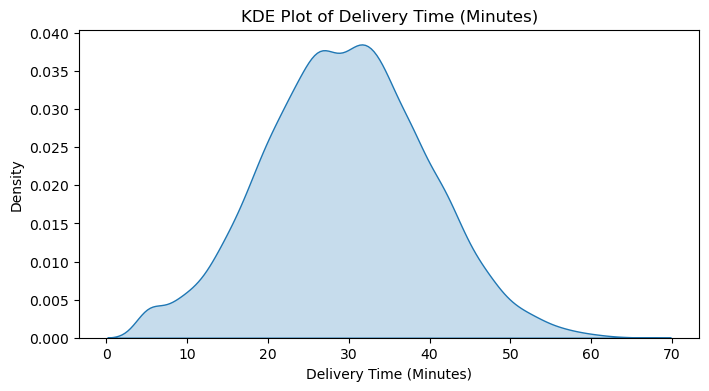

In [69]:
Ecom.plot_kde('Delivery Time (Minutes)')

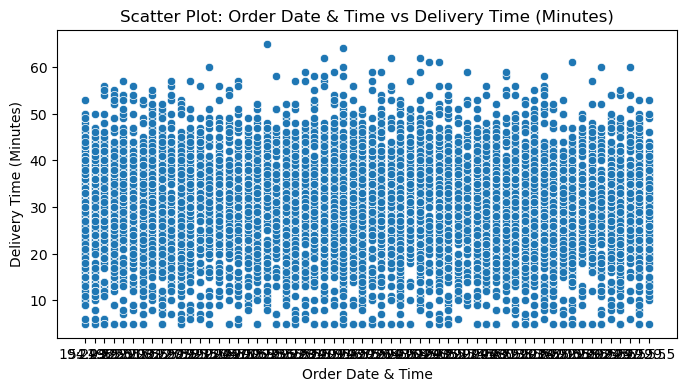

In [3]:
Ecom.plot_scatter('Order Date & Time','Delivery Time (Minutes)')

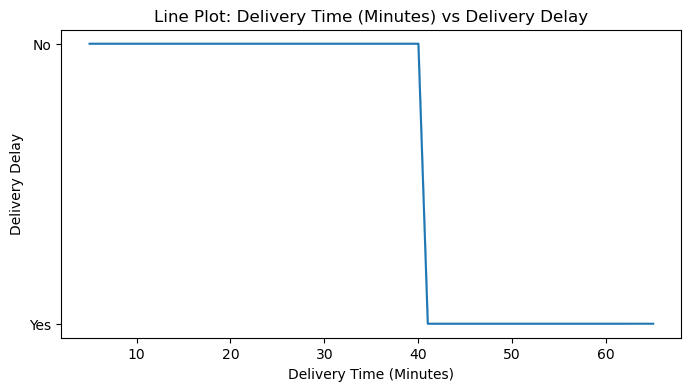

In [4]:
Ecom.plot_line('Delivery Time (Minutes)','Delivery Delay')

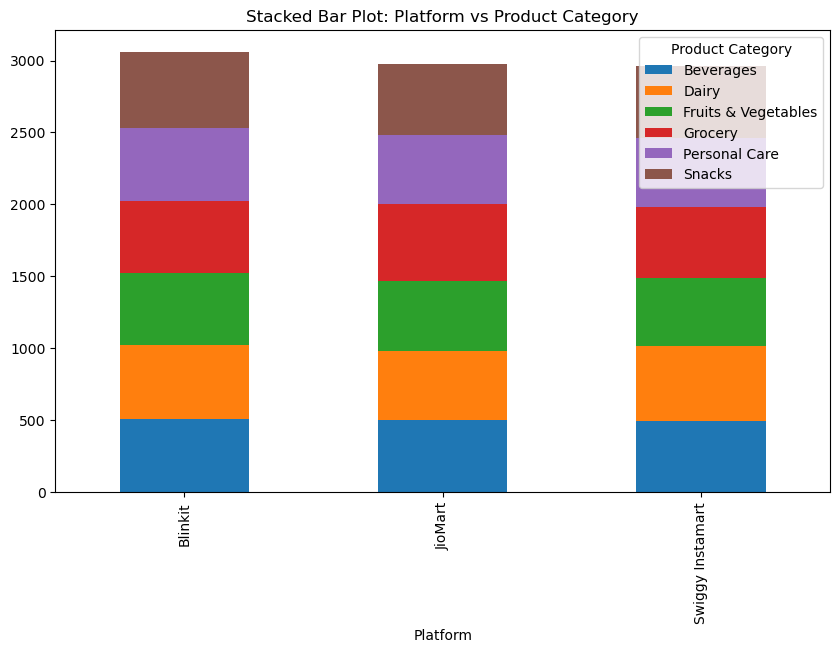

In [5]:
Ecom.plot_stacked_bar('Platform','Product Category')

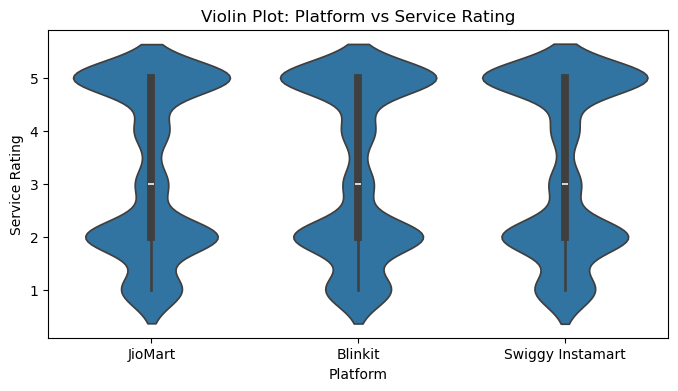

In [9]:
Ecom.plot_violin('Platform','Service Rating')

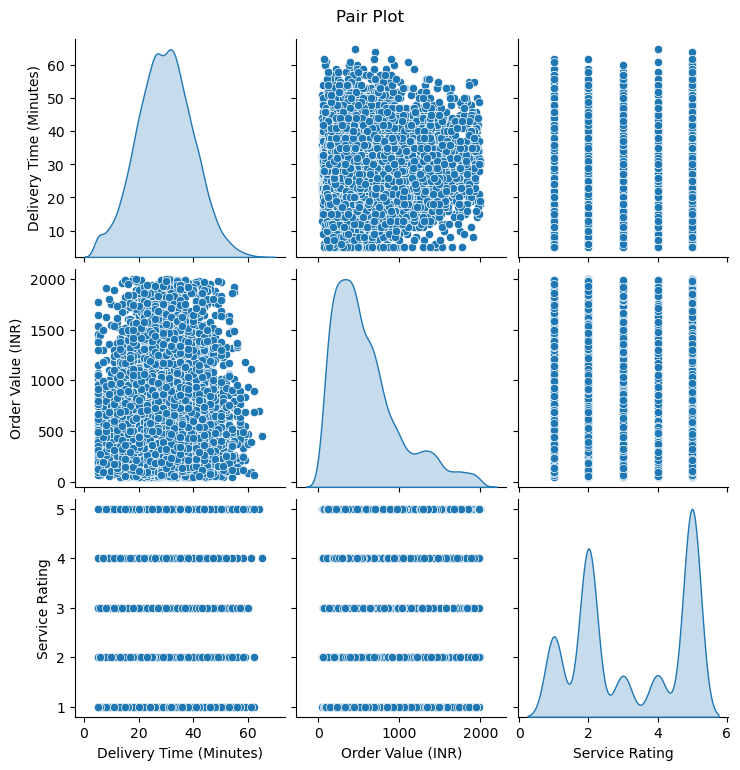

In [10]:
Ecom.plot_pair()

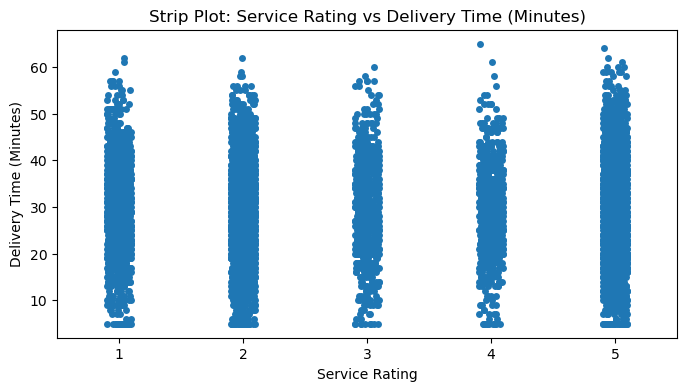

In [11]:
Ecom.plot_strip('Service Rating','Delivery Time (Minutes)')

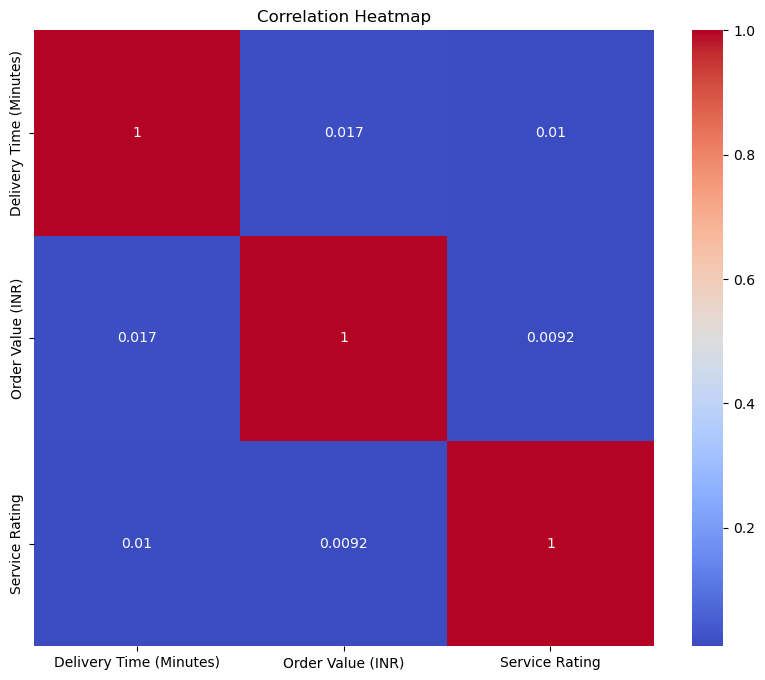

In [4]:
Ecom.correlation_heatmap()

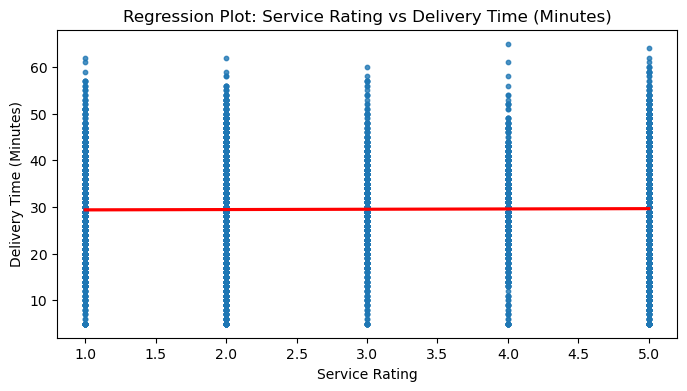

In [5]:
Ecom.regression_plot('Service Rating','Delivery Time (Minutes)')

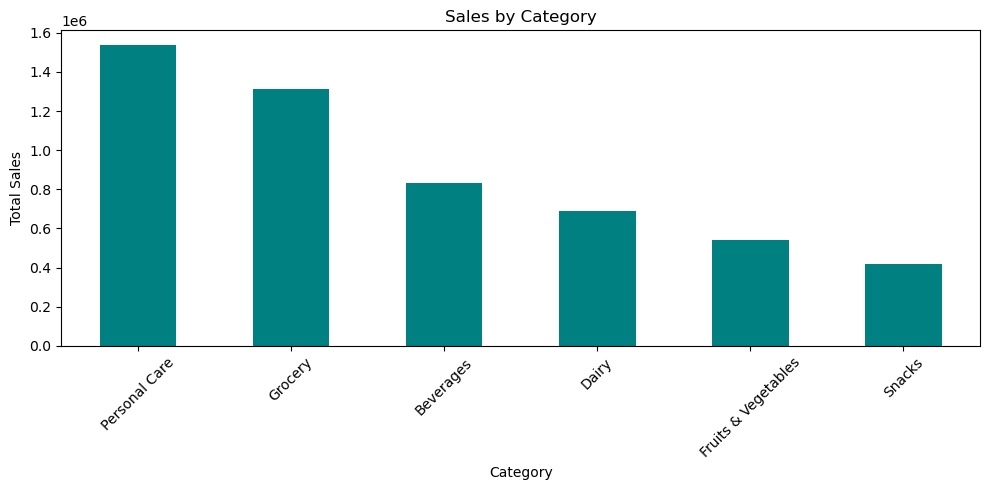

In [11]:
Ecom.sales_by_category(category_col='Product Category', sales_col='Order Value (INR)')

In [18]:
Ecom.chi_square('Product Category', 'Refund Requested')

0.6059830260511276

In [20]:
correlations = Ecom.continuous_vs_continuous_correlation()
for col1, col2, corr_value in correlations[:10]:  
    print(f"{col1} vs {col2}: correlation = {corr_value:.4f}")

Delivery Time (Minutes) vs Order Value (INR): correlation = 0.0167
Delivery Time (Minutes) vs Service Rating: correlation = 0.0102
Order Value (INR) vs Service Rating: correlation = 0.0092


In [21]:
Ecom.anova_test('Order Value (INR)')

,Feature,ANOVA_p_value
0,Platform,0.7594
1,Order Date & Time,0.2805
2,Product Category,0.0000
3,Customer Feedback,0.7080
4,Delivery Delay,0.5787
5,Refund Requested,0.3263


In [22]:
Ecom.t_test('Refund Requested', 'Order Value (INR)')

0.32633815096901353